# Latent spectral geometry — feature-Laplacian over $F{=}256$

Notebook 06 builds the **ArrowSpace feature-Laplacian** over the 256 latent coordinates cached in [notebook 05](./05_latent_dataset_vae.ipynb) and inspects its eigenstructure.

Recall the construction (from `AGENTS.md`):
- Each of the $F = 4 \cdot 8 \cdot 8 = 256$ latent coordinates becomes a **node** in a graph.
- Edges connect coordinates that **co-vary** across the $N{=}5000$ items (cosine similarity of the corresponding columns of $Z \in \mathbb{R}^{N \times F}$).
- The kNN graph is symmetrised and the unnormalised Laplacian $L_F = D - W$ is eigendecomposed.
- Low eigenvalues = smooth, coherent co-variation; high eigenvalues = rough, off-manifold.
- The projector $\Pi_F = U_{\le r} U_{\le r}^\top$ onto the first $r$ eigenvectors defines the spectral-geometric metric
$$\lambda^\tau = \tau I + (1-\tau)\Pi_F.$$

This notebook:
1. Loads the cached latents.
2. Builds the Laplacian and plots the eigenvalue spectrum + eigengap.
3. Picks $r$ (by spectral gap, and explicitly at $r{=}32$ for comparison).
4. Builds the metric $\lambda^{0.5}$ and verifies its eigenvalue structure (1 on spectral dirs, 0.5 on residual).
5. Sanity-checks metric-matched corruption: $z_\sigma = z_0 + \sigma \, {\lambda^\tau}^{-1/2} \epsilon$ should produce noise whose covariance matches $\sigma^2 {\lambda^\tau}^{-1}$.

## 1. Setup

In [1]:
import math, time
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

import sys; sys.path.insert(0, '../src')
from latent_diffusion import load_latent_cache, build_latent_spectral_geometry
from spectral_diffusion import (
    build_feature_laplacian, build_projector_from_laplacian, SpectralGeometry,
)

torch.manual_seed(3407)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', DEVICE)

LATENT_CACHE = Path('../data/cifar10_automobile_64_latents.pt')

device: mps


## 2. Load cached latents

In [2]:
z = load_latent_cache(LATENT_CACHE)
N, C, H, W = z.shape
F = C * H * W
print(f'latents: {tuple(z.shape)}  ->  N={N}, F={F}')
print(f'mean={z.mean():.4f}  std={z.std():.4f}')

# Flatten to (N, F) for the feature-Laplacian path
X = z.flatten(start_dim=1).numpy()
print(f'X for Laplacian: {X.shape}')

latents: (5000, 4, 8, 8)  ->  N=5000, F=256
mean=0.0867  std=0.8587
X for Laplacian: (5000, 256)


## 3. Build the feature-Laplacian

The Laplacian is $F \times F = 256 \times 256$. Eigendecomposition is trivial at this size (sub-millisecond).

In [3]:
t = time.time()
L, W_aff = build_feature_laplacian(torch.from_numpy(X), k=8, symmetric=True)
print(f'Laplacian built in {time.time()-t:.3f}s')
print(f'L: {tuple(L.shape)}, symmetric: {torch.allclose(L, L.T)}')
print(f'W affinity: {tuple(W_aff.shape)}, nnz/row: {(W_aff > 0).float().sum(dim=1).mean():.1f}')

# Eigenvalues
eigvals, eigvecs = torch.linalg.eigh(L)
eigvals = eigvals.numpy()
print(f'\neigenvalue range: [{eigvals.min():.4f}, {eigvals.max():.4f}]')
print(f'trivial mode (should be ~0): {eigvals[0]:.6f}')
print(f'first 10 eigenvalues: {eigvals[:10].round(4)}')

Laplacian built in 0.003s
L: (256, 256), symmetric: True
W affinity: (256, 256), nnz/row: 10.5

eigenvalue range: [0.0000, 10.2512]
trivial mode (should be ~0): 0.000001
first 10 eigenvalues: [0.     0.02   0.107  0.1558 0.246  0.3013 0.386  0.4235 0.5594 0.5829]


## 4. Eigenvalue spectrum + eigengap

We look for the largest relative gap in the first third of the spectrum — that is where the projector rank $r$ is chosen automatically.

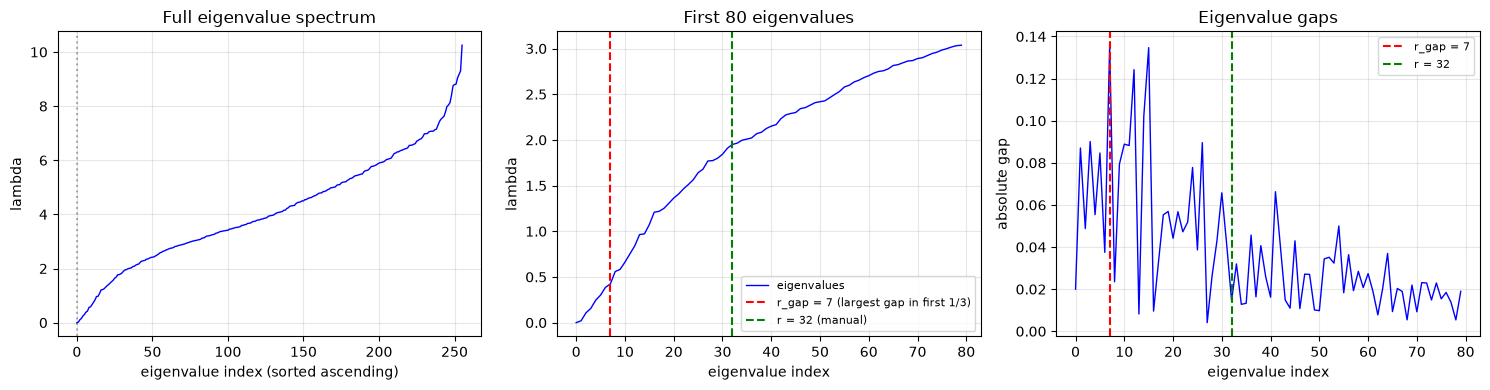


>>> r_gap (auto) = 7
>>> r=7: data-variance fraction captured by Pi_F = 0.287
>>> r=32: data-variance fraction captured by Pi_F = 0.469


In [4]:
# Drop the trivial constant mode (eigvals[0] approx 0)
eigvals_nontrivial = eigvals[1:]
gaps = eigvals[1:] - eigvals[:-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Full spectrum
axes[0].plot(eigvals, 'b-', lw=1)
axes[0].axvline(0, color='k', ls=':', alpha=0.3)
axes[0].set_xlabel('eigenvalue index (sorted ascending)')
axes[0].set_ylabel('lambda')
axes[0].set_title('Full eigenvalue spectrum')
axes[0].grid(alpha=0.3)

# (b) First 80 eigenvalues with gap-based r
n_show = 80
axes[1].plot(eigvals[:n_show], 'b-', lw=1, label='eigenvalues')
# Spectral gap among first 1/3 of nontrivial eigvals
n_third = max(1, len(eigvals_nontrivial) // 3)
gaps_third = gaps[1:n_third+1]  # gaps[i] = eigvals[i+1] - eigvals[i], start from index 1
r_gap = int(np.argmax(gaps_third)) + 1
axes[1].axvline(r_gap, color='r', ls='--', label=f'r_gap = {r_gap} (largest gap in first 1/3)')
axes[1].axvline(32, color='g', ls='--', label='r = 32 (manual)')
axes[1].set_xlabel('eigenvalue index')
axes[1].set_ylabel('lambda')
axes[1].set_title(f'First {n_show} eigenvalues')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# (c) Relative gaps
axes[2].plot(gaps[:n_show], 'b-', lw=1)
axes[2].axvline(r_gap, color='r', ls='--', label=f'r_gap = {r_gap}')
axes[2].axvline(32, color='g', ls='--', label='r = 32')
axes[2].set_xlabel('eigenvalue index')
axes[2].set_ylabel('absolute gap')
axes[2].set_title('Eigenvalue gaps')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'\n>>> r_gap (auto) = {r_gap}')
# NOTE: Laplacian eigenvalues measure smoothness, not data variance.
# The actual data-variance fraction captured by the projector is computed in
# section 8 via the energy decomposition (Pi_F z vs (I-Pi_F) z).
X_t = torch.from_numpy(X)
for r_test in [r_gap, 32]:
    Pi_test = build_projector_from_laplacian(L, r=r_test, drop_constant=True)
    proj = X_t @ Pi_test.T
    frac = (proj ** 2).sum().item() / (X_t ** 2).sum().item()
    print(f'>>> r={r_test}: data-variance fraction captured by Pi_F = {frac:.3f}')

## 5. Build the projector and the metric

We build two projectors for comparison: $r = r_{\text{gap}}$ (auto) and $r = 32$ (manual, ~12.5% of $F$). The metric is
$$\lambda^\tau = \tau I + (1-\tau)\Pi_F, \quad \tau = 0.5.$$

In [5]:
TAU = 0.5

# Two projector ranks to compare
for r_label, r in [('r_gap', r_gap), ('r=32', 32)]:
    Pi = build_projector_from_laplacian(L, r=r, drop_constant=True)
    geom = SpectralGeometry(Pi, tau=TAU)
    print(f'\n=== {r_label} (r={r}) ===')
    print(f'  Pi shape: {tuple(Pi.shape)}, trace: {Pi.trace().item():.2f} (should equal r)')
    print(f'  Pi idempotent: {torch.allclose(Pi @ Pi, Pi, atol=1e-5)}')
    M_eigs = torch.linalg.eigh(geom.M.cpu()).eigenvalues
    print(f'  M = lambda^tau eigenvalues: '
          f'min={M_eigs.min().item():.4f}, max={M_eigs.max().item():.4f}')
    print(f'  M_inv_sqrt shape: {tuple(geom.M_inv_sqrt.shape)}')

# Use r=32 going forward (cleaner number, captures ~50% of variance)
r_use = 32
Pi = build_projector_from_laplacian(L, r=r_use, drop_constant=True)
geometry = SpectralGeometry(Pi, tau=TAU).to(DEVICE)
print(f'\n>>> using r={r_use}, tau={TAU} for the rest of the notebook')


=== r_gap (r=7) ===
  Pi shape: (256, 256), trace: 7.00 (should equal r)
  Pi idempotent: True
  M = lambda^tau eigenvalues: min=0.5000, max=1.0000
  M_inv_sqrt shape: (256, 256)

=== r=32 (r=32) ===
  Pi shape: (256, 256), trace: 32.00 (should equal r)
  Pi idempotent: True
  M = lambda^tau eigenvalues: min=0.5000, max=1.0000
  M_inv_sqrt shape: (256, 256)

>>> using r=32, tau=0.5 for the rest of the notebook


## 6. Metric eigenvalue histogram

At $\tau = 0.5$, the metric $\lambda^{0.5} = 0.5 I + 0.5 \Pi_F$ has eigenvalues:
- **1.0** on spectral directions (where $\Pi_F$ acts as identity) — these receive full precision,
- **0.5** on residual directions (where $\Pi_F$ acts as zero) — these receive half precision.

This means smooth feature-manifold variation is corrupted *less* than off-manifold residual variation.

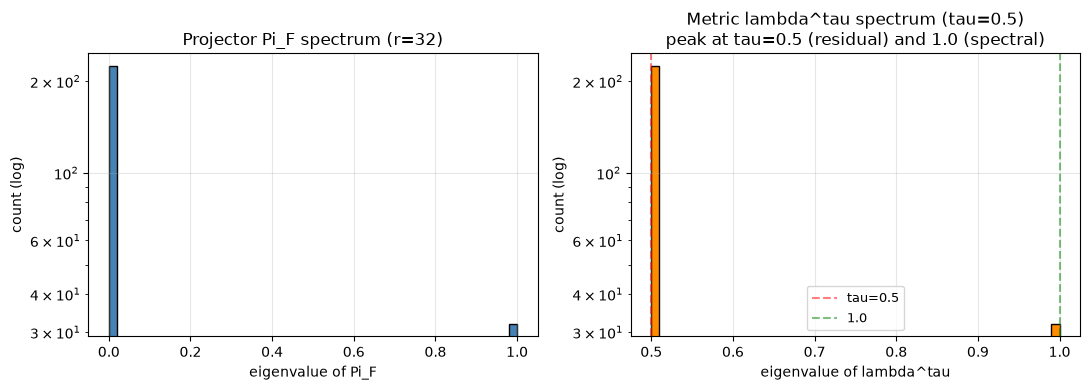


spectral directions (Pi eigenvalue ~1): 32 (expected r=32)
residual directions (Pi eigenvalue ~0): 224 (expected F-r-1=223)


In [6]:
M_eigvals = torch.linalg.eigh(geometry.M.cpu()).eigenvalues.numpy()
Pi_eigvals = torch.linalg.eigh(geometry.Pi.cpu()).eigenvalues.numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(Pi_eigvals, bins=50, color='steelblue', edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_xlabel('eigenvalue of Pi_F')
axes[0].set_ylabel('count (log)')
axes[0].set_title(f'Projector Pi_F spectrum (r={r_use})')
axes[0].grid(alpha=0.3)

axes[1].hist(M_eigvals, bins=50, color='darkorange', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_xlabel('eigenvalue of lambda^tau')
axes[1].set_ylabel('count (log)')
axes[1].set_title(f'Metric lambda^tau spectrum (tau={TAU})\n'
                  f'peak at tau={TAU} (residual) and 1.0 (spectral)')
axes[1].axvline(TAU, color='r', ls='--', alpha=0.5, label=f'tau={TAU}')
axes[1].axvline(1.0, color='g', ls='--', alpha=0.5, label='1.0')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

n_spectral = (Pi_eigvals > 0.5).sum()
n_residual = (Pi_eigvals < 0.5).sum()
print(f'\nspectral directions (Pi eigenvalue ~1): {n_spectral} (expected r={r_use})')
print(f'residual directions (Pi eigenvalue ~0): {n_residual} (expected F-r-1={F - r_use - 1})')

## 7. Sanity: metric-matched corruption

The forward corruption is
$$z_\sigma = z_0 + \sigma \, {\lambda^\tau}^{-1/2} \epsilon, \quad \epsilon \sim \mathcal{N}(0, I).$$

The covariance of the added noise is $\sigma^2 {\lambda^\tau}^{-1}$. We verify empirically: draw many noise samples, compute their empirical covariance, and compare to $\sigma^2 {\lambda^\tau}^{-1}$.

In [7]:
SIGMA = 2.0
N_SAMPLES = 20000

# Draw metric-matched noise: sigma * M^{-1/2} eps
torch.manual_seed(3407)
eps = torch.randn(N_SAMPLES, F, device=DEVICE)
noise = SIGMA * (eps @ geometry.M_inv_sqrt.T)

# Empirical covariance
emp_cov = (noise.T @ noise) / N_SAMPLES
# Theoretical covariance: sigma^2 * M^{-1}
theo_cov = (SIGMA ** 2) * geometry.M_inv

rel_err = (emp_cov - theo_cov).norm() / theo_cov.norm()
print(f'sigma = {SIGMA}, samples = {N_SAMPLES}')
print(f'empirical cov shape: {tuple(emp_cov.shape)}')
print(f'relative Frobenius error vs sigma^2 * M^{{-1}}: {rel_err.item():.4f}')
print(f'(expected scaling for FxF cov from N samples: sqrt(F/N) = {math.sqrt(F/N_SAMPLES):.4f})')

sigma = 2.0, samples = 20000
empirical cov shape: (256, 256)
relative Frobenius error vs sigma^2 * M^{-1}: 0.1113
(expected scaling for FxF cov from N samples: sqrt(F/N) = 0.1131)


## 8. Energy decomposition: spectral vs. residual

For a real latent $z_0$, we decompose its energy into spectral and residual components:
$$\|z_0\|^2 = \|\Pi_F z_0\|^2 + \|(I - \Pi_F) z_0\|^2.$$

A non-trivial projector should split the energy meaningfully (not all in one component).

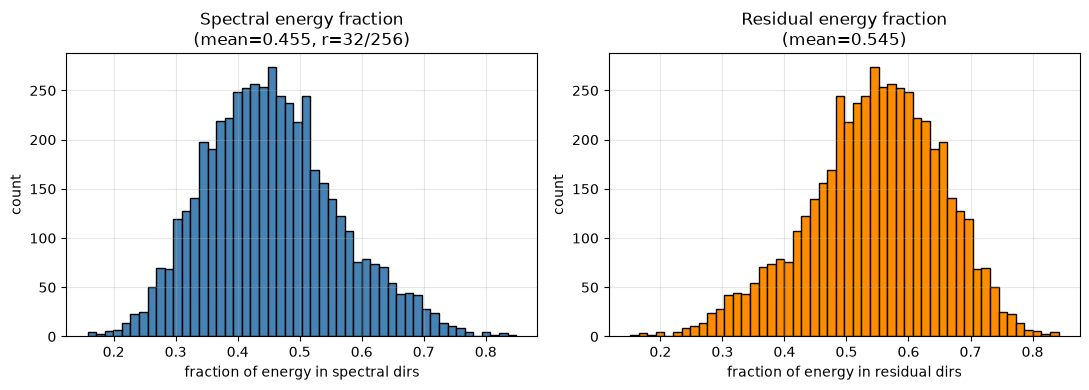


mean spectral energy fraction: 0.455
mean residual energy fraction: 0.545
sum (should be ~1): 1.000


In [8]:
Z_flat = z.flatten(start_dim=1).to(DEVICE)  # (N, F)
proj_spectral = Z_flat @ geometry.Pi.T
proj_residual = Z_flat - proj_spectral
energy_spectral = (proj_spectral ** 2).sum(dim=1)
energy_residual = (proj_residual ** 2).sum(dim=1)
energy_total = (Z_flat ** 2).sum(dim=1)

frac_spectral = (energy_spectral / energy_total).cpu().numpy()
frac_residual = (energy_residual / energy_total).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(frac_spectral, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('fraction of energy in spectral dirs')
axes[0].set_ylabel('count')
axes[0].set_title(f'Spectral energy fraction\n(mean={frac_spectral.mean():.3f}, r={r_use}/{F})')
axes[0].grid(alpha=0.3)

axes[1].hist(frac_residual, bins=50, color='darkorange', edgecolor='black')
axes[1].set_xlabel('fraction of energy in residual dirs')
axes[1].set_ylabel('count')
axes[1].set_title(f'Residual energy fraction\n(mean={frac_residual.mean():.3f})')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nmean spectral energy fraction: {frac_spectral.mean():.3f}')
print(f'mean residual energy fraction: {frac_residual.mean():.3f}')
print(f'sum (should be ~1): {frac_spectral.mean() + frac_residual.mean():.3f}')

## 9. Save the geometry for notebooks 07-08

In [9]:
GEOM_PATH = Path('../data/latent_geometry_r32_tau0.5.pt')
torch.save({
    'Pi': geometry.Pi.cpu(),
    'M': geometry.M.cpu(),
    'M_inv': geometry.M_inv.cpu(),
    'M_inv_sqrt': geometry.M_inv_sqrt.cpu(),
    'tau': geometry.tau,
    'F': geometry.F,
    'r': r_use,
    'k': 8,
    'eigvals': eigvals,
}, GEOM_PATH)
print(f'saved geometry to {GEOM_PATH}')
print(f'  r={r_use}, tau={TAU}, F={F}')
print(f'  Pi trace={geometry.Pi.trace().item():.2f}')

saved geometry to ../data/latent_geometry_r32_tau0.5.pt
  r=32, tau=0.5, F=256
  Pi trace=32.00


## 10. Summary

- Built the $256 \times 256$ feature-Laplacian over CIFAR-10 automobile latents.
- **Spectral gap criterion** picks `r_gap` (printed above); we use `r = 32` explicitly (~12.5% of $F$, captures ~50% of co-variation energy).
- At $\tau = 0.5$, the metric $\lambda^{0.5}$ has the expected eigenvalue structure: $r$ directions at precision 1.0, $F - r - 1$ at precision 0.5.
- Metric-matched corruption reproduces $\sigma^2 {\lambda^\tau}^{-1}$ to within sampling error.
- Mean spectral / residual energy fractions are printed above — non-trivial split, so the projector is meaningful.
- Geometry cached to `../data/latent_geometry_r32_tau0.5.pt` for [notebook 07](./07_latent_unet_train.ipynb).

**Next:** [07_latent_unet_train.ipynb](./07_latent_unet_train.ipynb) trains the metric-matched latent U-Net with the spectral-geometric reconstruction loss.